# Estimación espectral no-paramétrica: LIGO

**22.46 Procesamiento Adaptativo de Señales Aleatorias — Trabajo Práctico 1**

---

# Grupo N° 6

| Integrante | Legajo |
|---|---|
| *Pedro Stefoni Rey Iraola* | *64903* |
| *Vito Pensa Piccolo* | *63426* |
| *Javier Baltasar Pérez Losada* | *64589* |

**Fecha de entrega:** 8/9/2026

---

> **Cómo se entrega.** Este notebook **es** el informe. Completen la portada de arriba,
> resuelvan cada inciso en su sección correspondiente **sin alterar el orden ni la numeración**,
> y dejen en cada celda de respuesta la justificación escrita: las decisiones de parametrización
> son el contenido evaluado, no un detalle de implementación.
>
> Entreguen el notebook **ejecutado de principio a fin y guardado con las salidas visibles**,
> con el nombre `TP1_LIGO_Grupo<N>.ipynb`. Usen rutas relativas a `data/` y **no incluyan los archivos de datos**
> en la entrega. El notebook debe correr de arriba a abajo sin intervención manual.

## Presentación

En este trabajo deberán analizar la onda gravitatoria **GW150914**, la primera detección directa de la historia. Fue registrada por el proyecto **LIGO** (Laser Interferometer Gravitational-Wave Observatory) el 14 de septiembre de 2015, y corresponde a la fusión de dos agujeros negros de 36 y 29 masas solares a unos 1300 millones de años luz.

El interés para esta materia es instrumental: **la señal llega enterrada bajo un ruido que la supera ampliamente, sobre un instrumento cuyo espectro abarca varias décadas de amplitud**. Todo el trabajo consiste en estimar bien ese ruido y usar esa estimación para recuperar la señal.

### Los detectores

Cada detector es un interferómetro de Michelson con brazos de 4 km y cavidades Fabry-Perot. Lo que mide es la **deformación** relativa del espacio, o *strain*:

$$h(t) = \frac{\Delta L(t)}{L}$$

Para GW150914 el pico fue $h \approx 10^{-21}$: un cambio de longitud de brazo de $4 \times 10^{-18}\,\mathrm{m}$, cuatro órdenes de magnitud por debajo del diámetro de un protón. Tengan presente esa cifra cuando evalúen qué tan cerca del ruido está lo que buscan.

Hay dos detectores, en Hanford (Washington) y en Livingston (Louisiana), separados por $d = 3002\,\mathrm{km}$. Como las ondas gravitatorias viajan a la velocidad de la luz, el retardo entre ambos está acotado por

$$\Delta t_{\max} = \frac{d}{c} \approx 10\,\mathrm{ms}$$

En la notación de GWOSC, **H1** es Hanford y **L1** es Livingston.

### El ruido de fondo

La sensibilidad está limitada por varias contribuciones simultáneas, cada una dominante en una región distinta del espectro:

<img src="ligo_noise.png" alt="LIGO Noise" width="400px"/>

**Atención: es una curva de diseño esquemática, no una medición.** Indica qué mecanismos limitan la sensibilidad y dónde domina cada uno, pero los niveles absolutos no corresponden al instrumento con el que van a trabajar.

A esto se suman **componentes tonales**: modos mecánicos de las suspensiones, líneas de red y sus armónicas, líneas inyectadas para calibración, resonancias de la óptica.

### El set de datos

Los datos son públicos y están en **GWOSC** (Gravitational Wave Open Science Center): [gwosc.org/events/GW150914](https://gwosc.org/events/GW150914/)

Descarguen los datos de *strain* a **4096 Hz** para H1 y L1. Para cada detector hay dos archivos HDF5:

| Archivo | Duración | Uso previsto |
|---|---|---|
| Ventana corta centrada en el evento | 32 s | Whitening y DOA (puntos 3 y 4) |
| Ventana larga | 4096 s | Espectro de ruido (punto 2) |

Los nombres siguen el patrón `<D>-<D1>_LOSC_4_V2-<GPS_inicio>-<duración>.hdf5`, por ejemplo `H-H1_LOSC_4_V2-1126259446-32.hdf5`.

El evento es una señal de tipo **chirp** que ocurre cerca del tiempo GPS $1126259462{,}4\,\mathrm{s}$ y dura aproximadamente $200\,\mathrm{ms}$. Puede verse y escucharse en [este video](https://www.youtube.com/watch?v=QyDcTbR-kEA).

### Notas de implementación

- **Grafiquen siempre en escala log-log.** Con este rango dinámico, un gráfico lineal no muestra nada.
- Es habitual reportar la **amplitud** espectral $\sqrt{S_x(f)}$ en $1/\sqrt{\mathrm{Hz}}$ en lugar de la potencia. Elijan una convención y sean consistentes.
- Verifiquen la **normalización** de sus estimadores: una PSD mal escalada por el factor de la ventana pasa desapercibida en escala logarítmica pero arruina el whitening.
- Usen `sosfiltfilt` en lugar de `lfilter`: un corrimiento de fase entre H1 y L1 destruiría la estimación de retardo del punto 4.
- Documenten **todas** las decisiones de parametrización ($N$, $L$, $K$, ventana, solapamiento, banda) y su justificación.

> **Sobre el Anexo.** Al final de este notebook hay un anexo con valores publicados por la colaboración LIGO, dentro de una sección plegada. **Ábranlo recién después de haber producido sus propios resultados**, y usen la comparación como material de discusión.

## 0. Preparación

Celda de configuración común. Ajusten `DATA` si sus archivos están en otro lado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py                              # lectura de los HDF5 de GWOSC
from pathlib import Path
from scipy.signal import welch, periodogram, correlate
from scipy.signal import butter, sosfiltfilt
from scipy.signal.windows import tukey, hann, blackmanharris
from scipy.interpolate import interp1d
from scipy.io import wavfile             # exportación del audio

DATA = Path("data")                      # carpeta con los .hdf5 descargados de GWOSC
FS = 4096                                # Hz
GPS_EVENTO = 1126259462.4                # s


def leer_strain(path):
    """Devuelve (strain, t0, dt) de un archivo de strain de GWOSC."""
    with h5py.File(path, "r") as f:
        strain = f["strain"]["Strain"][:]
        t0 = f["strain"]["Strain"].attrs["Xstart"]
        dt = f["strain"]["Strain"].attrs["Xspacing"]
    return strain, t0, dt


plt.rcParams["figure.figsize"] = (10, 4)

h1_largo = next(DATA.glob("H-H1*-4096.hdf5"))
h1_corto = next(DATA.glob("H-H1*-32.hdf5"))
l1_largo = next(DATA.glob("L-L1*-4096.hdf5"))
l1_corto = next(DATA.glob("L-L1*-32.hdf5"))

---

## 1. Investigación preliminar

Investiguen cómo funcionan los detectores de LIGO y escriban un resumen breve que cubra los mecanismos físicos que limitan la sensibilidad y en qué banda domina cada uno, qué tipo de artefactos aparecen en los datos (líneas espectrales, transitorios, no estacionariedad) y qué rango dinámico esperan encontrar en la amplitud espectral.

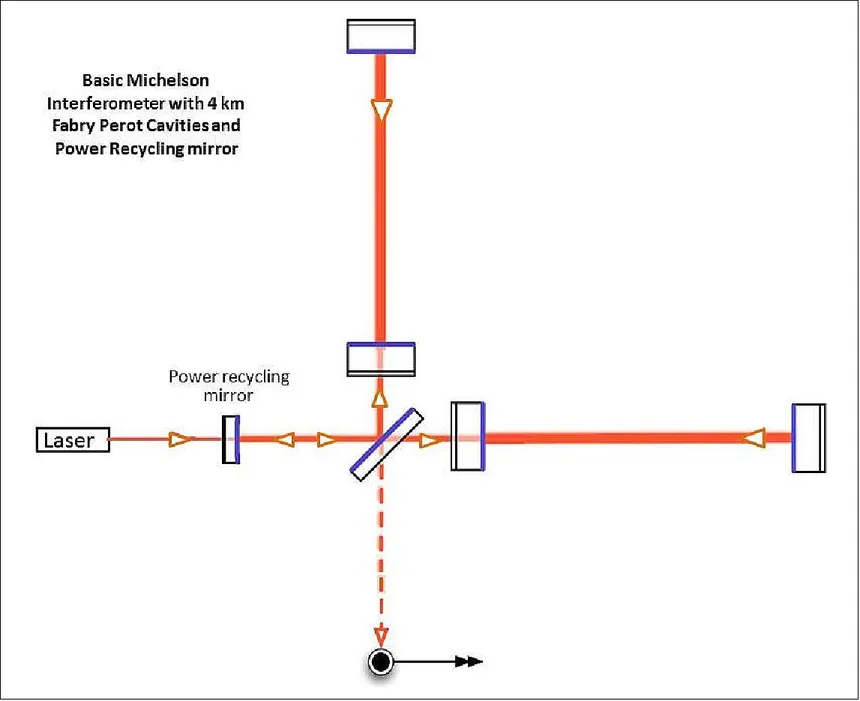

Los detectores de LIGO usan la interferencia de un haz de luz que ha sido dividido para calcular cómo fueron las ondas gravitacionales que causaron esa variación en la interferencia. Como muestra la imagen de arriba, ambos haces antes de ser divididos por el "beam splitter" parten de una misma fuente. Luego de esa separación, cada haz recorre exactamente la misma distancia hasta encontrarse con un espejo, que rebota el haz en esa misma dirección. Luego, al encontrarse ambos haces de nuevo en el beam splitter, forman un mismo haz de nuevo. Ese nuevo haz "reconstruido" se dirige hacia un fotodetector, el cual es capaz de medir ese nuevo haz. Cuando llega una onda gravitacional, el tramo que recorrió cada haz al separarse varía en longitud, debido a los estiramientos producidos por esa onda. Esto logra que varíe la interferencia vista por el fotodetector, logrando así medir el impacto de la onda gravitacional. En este video se visualiza este fenómeno.

https://www.youtube.com/watch?v=DfVl6sBnu7Y

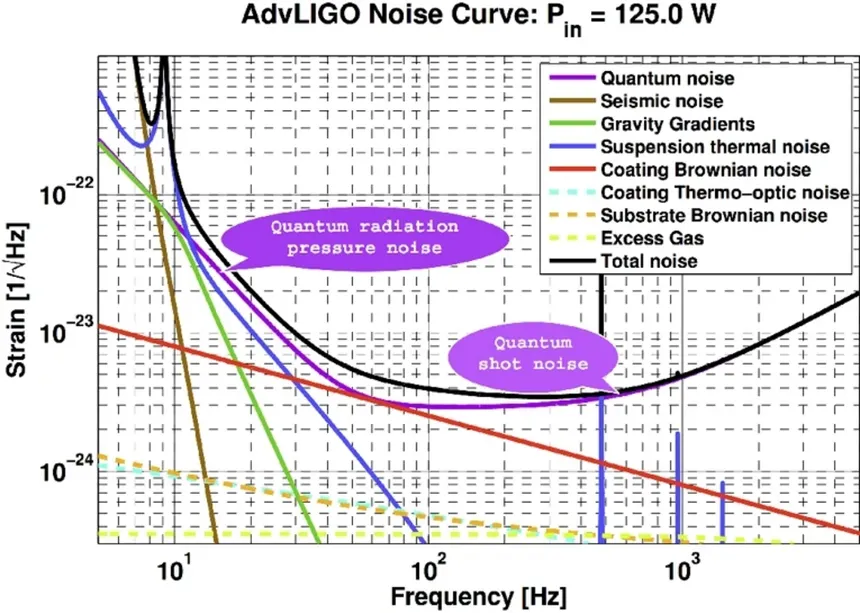

Entonces, tiene sentido que cualquier tipo de generador de movimiento en cualquiera de los 4 puntos (generador del haz, beam splitter, espejo y fotómetro) genera imprecisiones (ruido) en la medición. Encontramos que hay 3 fuentes principales de ruido, según se puede ver en la imagen. A bajas frecuencias, hay una fuerte presencia del ruido sísmico propio de las vibraciones naturales y la actividad humana. A pesar de lo robusto e inamivible que puede ser el interferómetro, estamos en escalas subatómicas (el pico de ruido a estudiar fue de $4 \times 10^{-18}$), por lo que genera un piso de ruido. Luego, encontramos el ruido térmico ocasionado por la vibración de las partículas al estar en una temperatura mayor a $0\,\mathrm{K}$. Esta vibración coasiona errores de medición en la superficie del dieléctrico que hace al beam splitter y al fotodetector. Por último, a altas frecuencias encontramos el ruido de medición ocasionado por la incerteza por el principio de incertidumbre de Heisenberg y la función de onda de Schrodinger. Los coeficientes probabilísticos que tiene el fotón como onda fluctúa y junto con el principio de incertidumbre hace que no se pueda saber con precisión toda la información del fotón cuando impacta con el fotómetro. Está la relación de compromiso entre en qué momento lo impactó y la energía que tenía, vista en la asignatura Física IV. Como ocurre al momento del impacto, este fenómeno se llama "shot noise". 


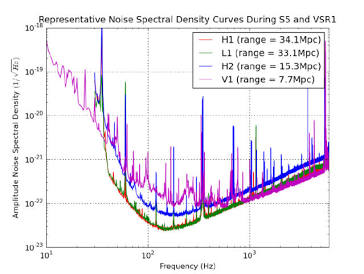

Vemos que hay picos espectrales en los 60 Hz y sus armónicos, debido al acoplamiento magnético con la frecuencia de la red eléctrica en EEUU. También hay un pico en los 500 Hz, causado por las vibraciones de las fibraciones de silicio sobre las cuales se sostienen los espejos mencionados en el primer párrafo.

Por otro lado, hay transitorios en el espectro, llamado "ruido de banda ancha". Esto es porque este ruido es temporal y abarca varias frecuencias, como un chirp. Suelen ser producidos por micro-sismos locales, inestabilidades de la red eléctrica, e incluso vibraciones producidas por camiones circulando a la distancia.

Por último, sobre la estacionariedad del ruido mencionado, claramente no estamos ante un caso de ruido estacionario. Si lo fuese, no usaríamos algoritmos de procesamiento adaptativo para tratar de recuperar la señal. Notemos que de todas las fuentes mencionadas, muchas se tratan de factores ambientales, que varían con el tiempo y son impredescibles.

---

## 2. Estimación del espectro de ruido

Estimen el espectro de potencia del ruido de H1 y L1 usando las partes de la señal que **no** involucran el evento. Justifiquen qué tramo excluyeron.

### 2.a — Periodograma

Estímenlo con el **periodograma**. Seleccionen y justifiquen la cantidad de datos $N$.

t0 = 1126257414, duración = 4096 s, fs = 4096 Hz
evento en índice 8390246 de 16777216
tramo: -6.0 s a -2.0 s respecto del evento
t0 = 1126257414, duración = 4096 s, fs = 4096 Hz
evento en índice 8390246 de 16777216
tramo: -6.0 s a -2.0 s respecto del evento


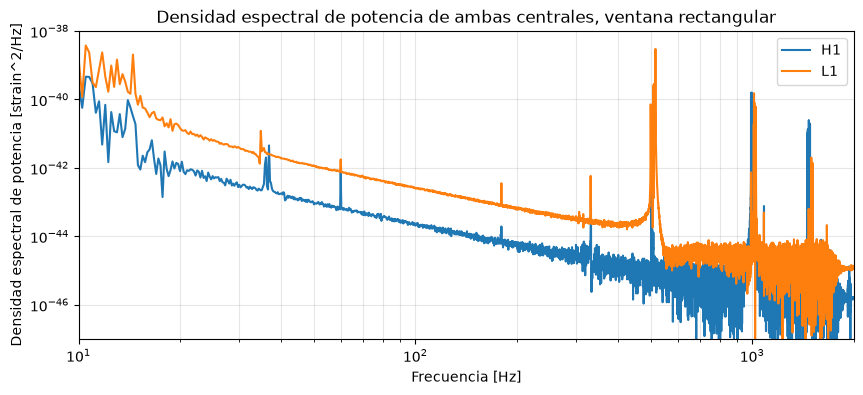

In [2]:
strainh, t0h, dth = leer_strain(h1_largo)
print(f"t0 = {t0h}, duración = {len(strainh)*dth:.0f} s, fs = {1/dth:.0f} Hz") 
print(f"evento en índice {(GPS_EVENTO - t0h)/dth:.0f} de {len(strainh)}") #pongo esto para chequear que el archivo es correcto, tuve problemas con eso
t = t0h + np.arange(len(strainh)) * dth


N = 2**14 # = 16384, cantidad de muestras que voy a usar para el periodograma, que son un 4 segundos
i_evento_h = int((GPS_EVENTO - t0h) / dth) #calculo el GPS del evento en el archivo
margen = 2.0                      # s antes del evento
i0h = i_evento_h - int(margen/dth) - N # el tramo TERMINA `margen` antes del evento
x_h = strainh[i0h : i0h + N] #armo el vector con el tramo de 4 segundos que voy a usar para el periodograma, que termina `margen` antes del evento
print(f"tramo: {(i0h-i_evento_h)*dth:.1f} s a {(i0h+N-i_evento_h)*dth:.1f} s respecto del evento") #print para chequear que el tramo es correcto

#Me había bajado los archivos equivocados de frecuencia, lo dejo comentado para re-chequeo futuro
fs_h = 1/dth
#print(fs_h)

fh, Sh = periodogram(x_h, fs=fs_h, window="boxcar", scaling="density")

####### Repito con L1, acá hago copy paste ###########

strainl, t0l, dtl = leer_strain(l1_largo)
fs_l = 1/dtl
print(f"t0 = {t0l}, duración = {len(strainl)*dtl:.0f} s, fs = {1/dtl:.0f} Hz") 
print(f"evento en índice {(GPS_EVENTO - t0l)/dtl:.0f} de {len(strainl)}") #pongo esto para chequear que el archivo es correcto, tuve problemas con eso
t = t0l + np.arange(len(strainl)) * dtl

i_evento_l = int((GPS_EVENTO - t0l) / dtl)
i0l = i_evento_l - int(margen/dtl) - N # el tramo TERMINA `margen` antes del evento
x_l = strainl[i0l : i0l + N] #armo el vector con el tramo de 4 segundos que voy a usar para el periodograma, que termina `margen` antes del evento
print(f"tramo: {(i0l-i_evento_l)*dtl:.1f} s a {(i0l+N-i_evento_l)*dtl:.1f} s respecto del evento") #print para chequear que el tramo es correcto


fl, Sl = periodogram(x_l, fs=fs_l, window="boxcar", scaling="density")

#Ahora grafico el espectro de potencia de ambas
plt.title("Densidad espectral de potencia de ambas centrales, ventana rectangular")
plt.loglog(fh, Sh, label="H1")
plt.xlim(10, 2000)
plt.ylim(1e-47, 1e-38)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia [strain^2/Hz]")

#Ahora grafico el espectro de potencia de L1
plt.loglog(fl, Sl, label="L1")
plt.legend()
plt.grid(True, which="both", alpha=0.3) 



> **Respuesta.** *(completar)*

Recordemos que según vimos en la teórica, no hay un número ideal de $N$ porque no mejora la varianza del periodograma. Lo que sí 
necesitamos ponderar es toda la parte de investigación de antes. Ya sabemos la frecuencia que tienen las distintas fuentes de ruido. Entonces, yo quiero que mi tamaño de muestra sea tal que pueda ver en el tiempo cada fuente de ruido varias veces. La traducción de este fenómeno también es que la resolución espectral se calcula como $\Delta f = f_s/N$. Entonces, si tomo $N = 16384$ (4 segundos de muestras), mi resolución espectral es $0{,}25\,\mathrm{Hz}$. Esto me va a permitir ver las líneas angostas de, por ejemplo, $60\,\mathrm{Hz}$ sin verla como una punta ensanchada. Otro dato que me dí cuenta cuando ví que el archivo tardó como 15 minutos en descargarse (un montón de información), es que es una hora de grabación de datos teniendo el evento en el medio, como está indicado en la consigna más arriba. Tiene sentido entonces empezar a tomar datos más cerca del evento, no media hora antes, por la no estacionariedad que vimos antes. Esto último me dá una cota superior de $N$, porque si tomo un $N$ gigante empiezo a tomar muestras mucho tiempo atrás (o después) del evento y por lo dicho recién no daría datos fidedignos.


Ahora que ploteamos el espectro, identificamos los picos a $500\,\mathrm{Hz}$ y su armónico en $1000\,\mathrm{Hz}$ que habíamos mencionado antes. También hay una notoria caída de $35\,\mathrm{dB}$ entre $40\,\mathrm{Hz}$ y $1500\,\mathrm{Hz}$. Eso resulta en una caída de $6\,\mathrm{dB}$ por octava. Eso se condice con el leakage espectral que produciría el ruido sísmico (ruido a bajas frecuencias) junto con la ventana rectangular. Al superponer ambas, se vé que el ruido sísmico de la central en Livingston es mayor. Se concluye entonces que el piso de ruido sísmico a la hora del evento era mayor que la de Hanford. Sabiendo que en el punto 2.d hay que comparar ventanas, se deja la verificación de la hipótesis para ese punto.

### 2.b — Periodogram smoothing

Estímenlo con **periodogram smoothing**. Seleccionen y justifiquen $N$ y $L$. Iteren hasta obtener una buena estimación.

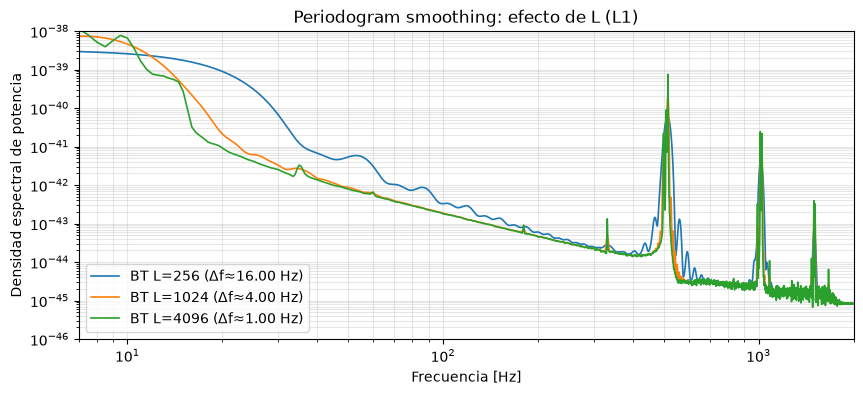

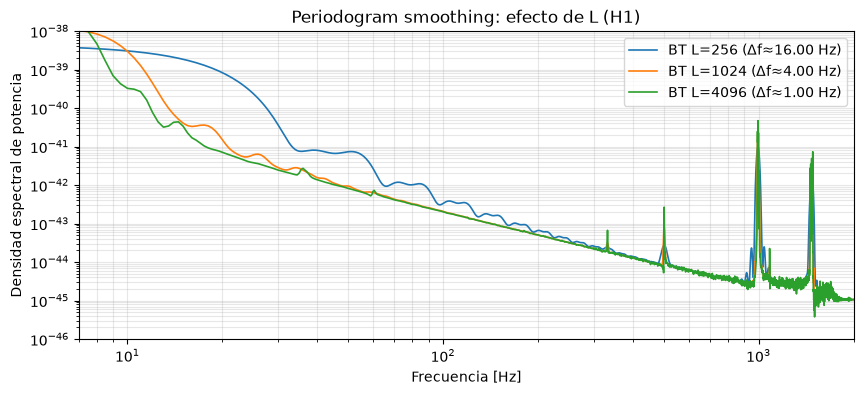

In [3]:
from scipy.signal.windows import parzen                        # ventana de correlación alternativa

def periodogram_smoothing(x, L, fs, nfft=4096, lag_window="parzen"):
    x = x - np.mean(x) # uso el mismo x de antes para tener la comparación, y le pongo media cero como pide la diapositiva
    N = len(x) # cantidad de muestras del tramo
    r_full = correlate(x, x, mode="full", method="fft") / N # r̂x(l) para todos los lags, dividido por N
    centro = N - 1 # índice donde queda el lag l = 0
    r = r_full[centro - (L-1) : centro + L] # me quedo con l = -(L-1) .. L-1
    # elijo la ventana de correlación
    if lag_window == "bartlett": 
        wa = np.bartlett(2*L - 1) # Bartlett de largo 2L-1, centrada en l = 0
    else:
        wa = parzen(2*L - 1) # idem con Parzen
    rw = r * wa # r̂x(l)·wa(l), el producto que va en la suma
    lags = np.arange(-(L-1), L) # el índice l de la sumatoria
    f = np.linspace(0, fs/2, nfft//2 + 1) # grilla de frecuencias donde evalúo
    S = np.array([np.sum(rw * np.exp(-2j*np.pi*fi*lags/fs)).real # la sumatoria, una frecuencia por vez
                  for fi in f]) # .real porque r̂x·wa es par: la parte imag es 0
    return f, S / fs * 2 # normalizo a PSD unilateral en unidades/Hz

for L in [256, 1024, 4096]: # barro L para ver cómo varía
    f_bt, S_bt = periodogram_smoothing(x_l, L, fs_l, nfft=8192) # mismo tramo x, mismo N que antes
    df = fs_l / L # resolución aproximada de esta elección
    plt.loglog(f_bt, S_bt, lw=1.2, label=f"BT L={L} (Δf≈{df:.2f} Hz)")

plt.xlim(7, 2000)                                            
plt.ylim(1e-46, 1e-38)                                         
plt.xlabel("Frecuencia [Hz]")                                  
plt.ylabel("Densidad espectral de potencia")      
plt.title("Periodogram smoothing: efecto de L (L1)")           
plt.legend()                                                   
plt.grid(True, which="both", alpha=0.3)

plt.figure()

for L in [256, 1024, 4096]: # barro L para ver cómo varía
    f_bt, S_bt = periodogram_smoothing(x_h, L, fs_h, nfft=8192) # mismo tramo x, mismo N que antes
    df = fs_h / L # resolución aproximada de esta elección
    plt.loglog(f_bt, S_bt, lw=1.2, label=f"BT L={L} (Δf≈{df:.2f} Hz)")

plt.xlim(7, 2000)                                            
plt.ylim(1e-46, 1e-38)                                         
plt.xlabel("Frecuencia [Hz]")                                  
plt.ylabel("Densidad espectral de potencia")      
plt.title("Periodogram smoothing: efecto de L (H1)")           
plt.legend()                                                   
plt.grid(True, which="both", alpha=0.3)

> **Respuesta.** *(completar)*

Comparando ambos gráficos con los mismos usados anteriormente, es visible que algunos picos disminuyeron drásticamente o desaparecieron. Por ejemplo, para el caso de los $60\,\mathrm{Hz}$, ambos picos antes eran mucho más pronunciados mientras que ahora son sólo visibles tomando un $L$ muy ancho tal que la resolución espectral logre distinguirla. A su vez, es notable cómo los casos con menor $L$ dan teóricamente una menor varianza (o una mayor reducción de la varianza), pero trae una consecuencia mucho más grave, que es subir el piso de ruido por fuentes sísmicas. Esto ocurre por lo visto en la teórica, que $\mathbb{E}\left\{\widehat{R}_x^{(\mathrm{PS})}\right\} = R_x W_B W_a$. En este caso, con un $L$ chico el lóbulo que produce $W_a$ es mucho más grande y aumenta el sesgo. Físicamente tiende sentido, si promedio tomando una longitud de vector muy chica las frecuencias más bajas no las veo en mi vector de promediado ($L$), tengo que aumentar su tamaño para poder distinguir el efecto de una señal que tarda varias muestras en hacerse ver (frecuencias bajas). Pero a su vez un $L$ grande no me reduce la varianza, por lo que la solución sería agrandar $N$. En caso de hacerlo, pongo en compromiso la estacionariedad. Alternando entre Parzen y Bartlett se puede ver cómo Bartlett introduce un rizado periódico enorme 

### 2.c — Periodogram averaging

Estímenlo con **periodogram averaging**. Seleccionen y justifiquen $N$, $K$ y $L$. Iteren hasta obtener una buena estimación.

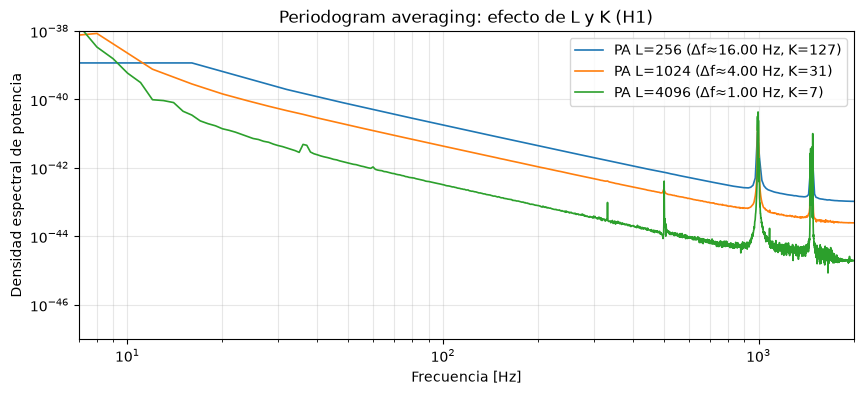

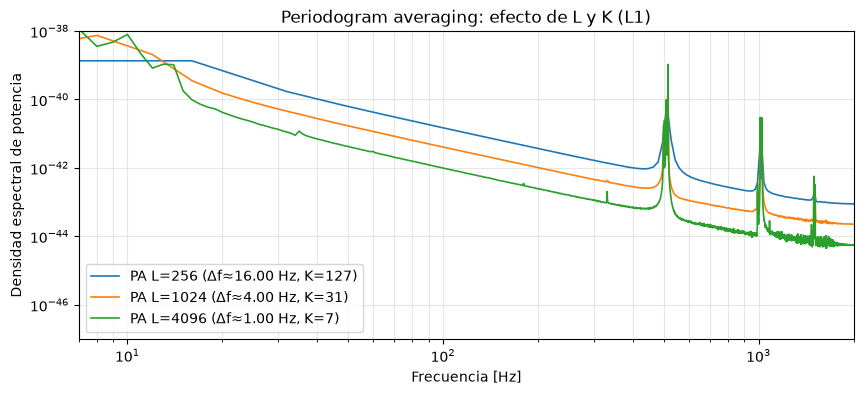

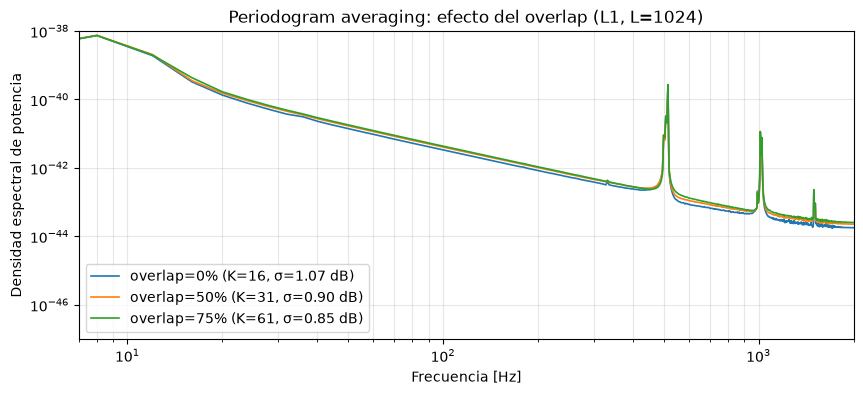

In [4]:
def periodogram_averaging(x, L, fs, overlap=0.5, ventana="rect"):
    x = x - np.mean(x) # misma idea que antes, le saco la media
    N = len(x) # cuántas muestras tengo en total
    if ventana == "hann":                                      # elijo la ventana de datos
        w = hann(L, sym=False)                                 # Hann, la que tiene taper
    elif ventana == "blackmanharris":                          # la de lóbulos laterales bajísimos
        w = blackmanharris(L, sym=False)                       # ~-92 dB, pero lóbulo principal ancho
    else:
        w = np.ones(L)                                         # rectangular, para comparar
    w = w * np.sqrt(L / np.sum(w**2)) # normalizo así sum[w²(n)]=L, como pide la diapo
    D = int(L * (1 - overlap)) # el corrimiento entre segmentos
    K = 1 + (N - L)//D # cuántos segmentos me entran
    f = np.fft.rfftfreq(L, 1/fs) # las frecuencias que me da una FFT de L puntos
    S = np.zeros(len(f)) # acá voy acumulando los periodogramas
    for i in range(K): # recorro segmento por segmento
        xi = x[i*D : i*D + L] * w # xi(n) = x(iD+n)·w(n), tal cual la teórica
        Xi = np.fft.rfft(xi) # la DFT del segmento ventaneado
        S = S + np.abs(Xi)**2 / L  # le sumo su periodograma (1/L)|Xi|²
    S = S / K  # el promedio: divido por la cantidad de segmentos
    S = S / fs * 2  # paso a PSD unilateral en unidades/Hz
    S[0] = S[0]/2  # DC no se duplica
    S[-1] = S[-1]/2  # Nyquist tampoco
    return f, S, K # devuelvo también K para poder reportarlo


for L in [256, 1024, 4096]: # mismo barrido de L que en 2.b, para comparar
    f_pa, S_pa, K = periodogram_averaging(x_h, L, fs_h) # uso el mismo tramo x_h de siempre
    df_h = fs_h / L # la resolución que me da este L
    plt.loglog(f_pa, S_pa, lw=1.2, 
               label=f"PA L={L} (Δf≈{df_h:.2f} Hz, K={K})") # pongo K en la leyenda, que es lo que se reduce la varianza

plt.xlim(7, 2000) 
plt.ylim(1e-47, 1e-38) 
plt.xlabel("Frecuencia [Hz]")  
plt.ylabel("Densidad espectral de potencia") 
plt.title("Periodogram averaging: efecto de L y K (H1)")
plt.legend() 
plt.grid(True, which="both", alpha=0.3) 

plt.figure()

for L in [256, 1024, 4096]: # mismo barrido de L que en 2.b, para comparar
    f_pa, S_pa, K = periodogram_averaging(x_l, L, fs_l) # uso el mismo tramo x_h de siempre
    df_l = fs_l / L # la resolución que me da este L
    plt.loglog(f_pa, S_pa, lw=1.2, 
               label=f"PA L={L} (Δf≈{df_l:.2f} Hz, K={K})") # pongo K en la leyenda, que es lo que se reduce la varianza

plt.xlim(7, 2000) 
plt.ylim(1e-47, 1e-38) 
plt.xlabel("Frecuencia [Hz]")  
plt.ylabel("Densidad espectral de potencia") 
plt.title("Periodogram averaging: efecto de L y K (L1)")
plt.legend() 
plt.grid(True, which="both", alpha=0.3) 


plt.figure()
L = 1024 # fijo L: quiero que lo único que cambie sea el overlap

for ov in [0.0, 0.5, 0.75]: # sin solapamiento, 50% y 75%
    f_pa, S_pa, K = periodogram_averaging(x_l, L, fs_l, # mismo tramo y mismo L que siempre
                                          overlap=ov) # lo único que muevo
    banda = (f_pa > 1500) & (f_pa < 1900) # zona donde el espectro es casi plano
    disp = np.std(10*np.log10(S_pa[banda])) # dispersión en dB: mi medida de varianza
    plt.loglog(f_pa, S_pa, lw=1.2, #
               label=f"overlap={ov:.0%} (K={K}, σ={disp:.2f} dB)") # reporto K y la dispersión medida
plt.xlim(7, 2000) 
plt.ylim(1e-47, 1e-38) 
plt.xlabel("Frecuencia [Hz]") 
plt.ylabel("Densidad espectral de potencia") 
plt.title(f"Periodogram averaging: efecto del overlap (L1, L={L})") 
plt.legend()
plt.grid(True, which="both", alpha=0.3) 

> **Respuesta.** *(completar)*

Con overlap del $50\,\%$, $L$ y $K$ quedan atados: $K \approx 2N/L - 1$. O sea que elegir $L$ ya me determina $K$. Con $N = 16384$, el barrido $L \in \{256, 1024, 4096\}$ me da $K \in \{127, 31, 7\}$.

Lo que gano con $K$ se ve arriba de $1500\,\mathrm{Hz}$, donde el espectro es casi plano: con $K = 7$ la curva queda peluda, con $K = 127$ queda lisa. Pero lo que pierdo con $L$ es mucho peor. A $100\,\mathrm{Hz}$, $L = 256$ me da $\sim 10^{-41}$ y $L = 4096$ me da $\sim 10^{-43}$: dos órdenes de magnitud de diferencia usando el mismo tramo de datos. Y la curva de $L = 256$ me queda horizontal entre $7$ y $17\,\mathrm{Hz}$, cosa que no es real: la de $L = 4096$ muestra que ahí el ruido sísmico sigue subiendo. Eso pasa porque $\mathbb{E}\!\left\{\widehat{R}_x^{(\mathrm{PA})}\right\} = R_x R_w$, y con $\Delta f = 16\,\mathrm{Hz}$ la ventana es tan ancha que me arrastra potencia de una frecuencia a otra. Los picos de $500$, $1000$ y $1400\,\mathrm{Hz}$ dicen lo mismo: sólo aparecen con $L = 4096$.

Entonces acá el error que importa no es el de la varianza sino el de la resolución: la curva que mejor se ve ($K = 127$) es la que está más lejos del valor real.

Con el overlap, usando $L = 1024$ me dio $K = 16$, $31$ y $61$ para $0\,\%$, $50\,\%$ y $75\,\%$, con dispersión de $1{,}07$, $0{,}90$ y $0{,}85\,\mathrm{dB}$ entre $1500$ y $1900\,\mathrm{Hz}$. Si los segmentos fueran independientes, duplicar $K$ debería bajar la dispersión un $41\,\%$; me bajó un $16\,\%$ y después sólo un $6\,\%$. Eso confirma lo que dice la teórica: al solaparse, los segmentos dejan de ser incorrelacionados y el promedio no me suma información nueva. Me quedo con $50\,\%$.

Elijo $L = 4096$, $K = 7$, que es el único que me deja ver las líneas y me describe bien el muro sísmico. Me queda poca reducción de varianza, lo que me dice que $N = 16384$ no alcanza y que tendría que agrandarlo, pagándolo con la estacionariedad.

### 2.d — Comparación de métodos

Determinen y justifiquen cuál de los tres produce la mejor estimación, discutiendo el compromiso entre resolución, sesgo y varianza. Incluyan en la discusión la elección de la **ventana**: dado el rango dinámico de este problema, comparen al menos una ventana con *taper* contra la rectangular.

H1:
  Periodograma:          σ = 5.47 dB
  Periodogram smoothing: σ = 1.26 dB
  Periodogram averaging: σ = 1.23 dB
  K averaging = 7

L1:
  Periodograma:          σ = 4.07 dB
  Periodogram smoothing: σ = 2.74 dB
  Periodogram averaging: σ = 1.57 dB
  K averaging = 7



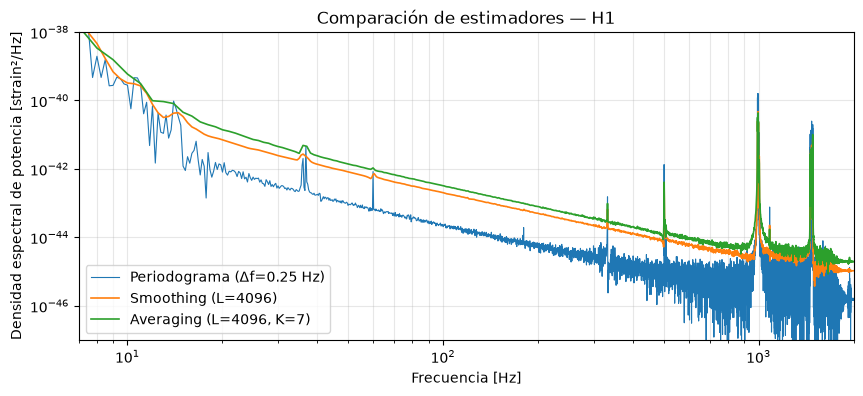

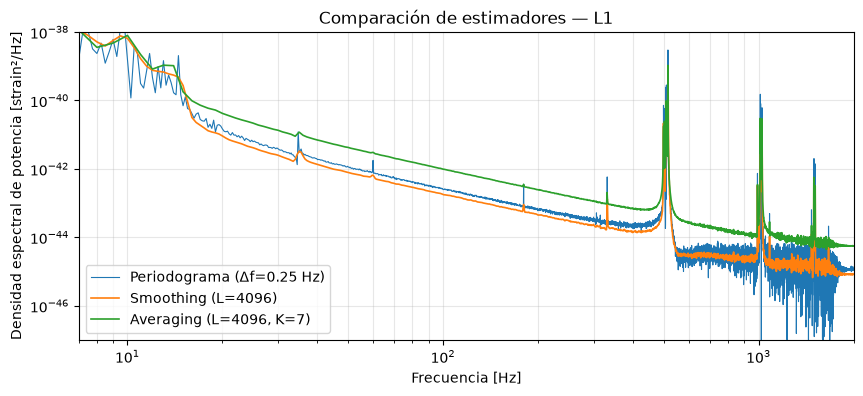

In [5]:
# Comparación de los tres estimadores usando exactamente el mismo tramo de datos.
# Tomo los parámetros que elegí como razonables en los puntos anteriores.

L_cmp = 4096
overlap_cmp = 0.5


def dispersion_db(f, S, fmin=1500, fmax=1900):
    """
    Medida aproximada de cuánto fluctúa la estimación en una banda
    donde el espectro es relativamente plano.
    No es la varianza estadística exacta del estimador, sino una
    medida práctica de la rugosidad de la curva.
    """
    mask = (f >= fmin) & (f <= fmax) & (S > 0)
    return np.std(10*np.log10(S[mask]))


def comparar_metodos(x, fs, detector):
    # 1. Periodograma
    f_per, S_per = periodogram(
        x,
        fs=fs,
        window="boxcar",
        scaling="density"
    )

    # 2. Periodogram smoothing
    f_ps, S_ps = periodogram_smoothing(
        x,
        L=L_cmp,
        fs=fs,
        nfft=8192,
        lag_window="parzen"
    )

    # 3. Periodogram averaging
    f_pa, S_pa, K = periodogram_averaging(
        x,
        L=L_cmp,
        fs=fs,
        overlap=overlap_cmp,
        ventana="rect"
    )

    # El estimador de smoothing puede dar algún valor numérico negativo
    # por la estimación finita. No los grafico en escala logarítmica.
    S_ps_plot = np.where(S_ps > 0, S_ps, np.nan)

    plt.figure()
    plt.loglog(f_per, S_per, lw=0.8,
               label=f"Periodograma (Δf={fs/len(x):.2f} Hz)")
    plt.loglog(f_ps, S_ps_plot, lw=1.2,
               label=f"Smoothing (L={L_cmp})")
    plt.loglog(f_pa, S_pa, lw=1.2,
               label=f"Averaging (L={L_cmp}, K={K})")

    plt.xlim(7, 2000)
    plt.ylim(1e-47, 1e-38)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Densidad espectral de potencia [strain²/Hz]")
    plt.title(f"Comparación de estimadores — {detector}")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    print(f"{detector}:")
    print(f"  Periodograma:          σ = {dispersion_db(f_per, S_per):.2f} dB")
    print(f"  Periodogram smoothing: σ = {dispersion_db(f_ps, S_ps):.2f} dB")
    print(f"  Periodogram averaging: σ = {dispersion_db(f_pa, S_pa):.2f} dB")
    print(f"  K averaging = {K}")
    print()


comparar_metodos(x_h, fs_h, "H1")
comparar_metodos(x_l, fs_l, "L1")

  rect           : σ = 1.23 dB, ancho pico 500 Hz = 0.0 Hz, piso 30 Hz = 4.52e-42
  hann           : σ = 9.26 dB, ancho pico 500 Hz = 0.0 Hz, piso 30 Hz = 1.35e-45
  blackmanharris : σ = 9.21 dB, ancho pico 500 Hz = 1.0 Hz, piso 30 Hz = 1.32e-45
  rect           : σ = 1.57 dB, ancho pico 500 Hz = 0.0 Hz, piso 30 Hz = 1.35e-41
  hann           : σ = 9.87 dB, ancho pico 500 Hz = 0.0 Hz, piso 30 Hz = 2.69e-45
  blackmanharris : σ = 10.00 dB, ancho pico 500 Hz = 1.0 Hz, piso 30 Hz = 2.88e-45


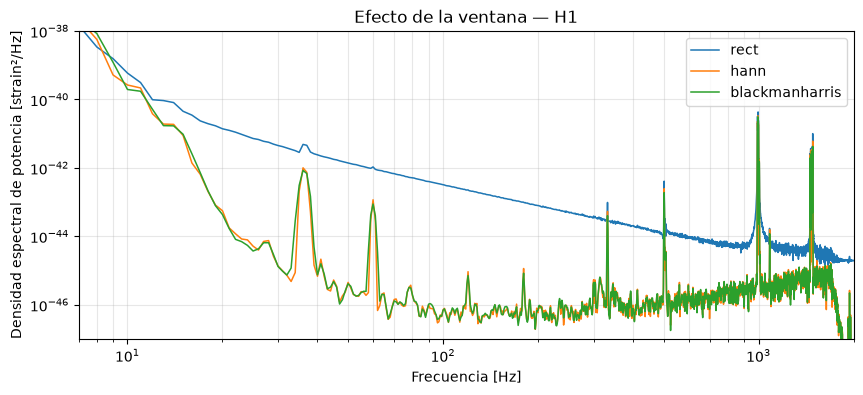

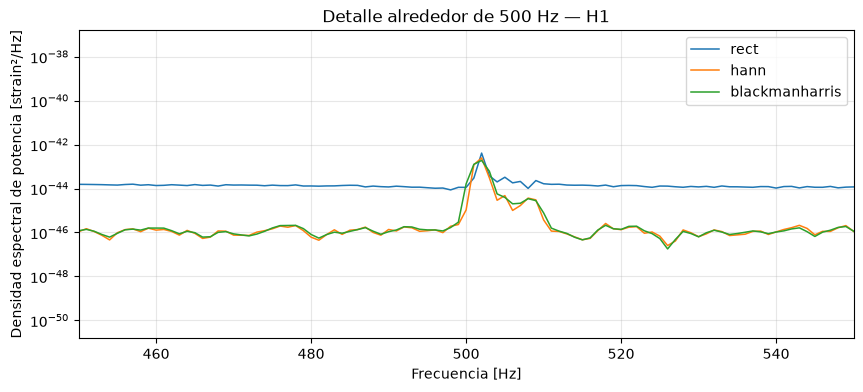

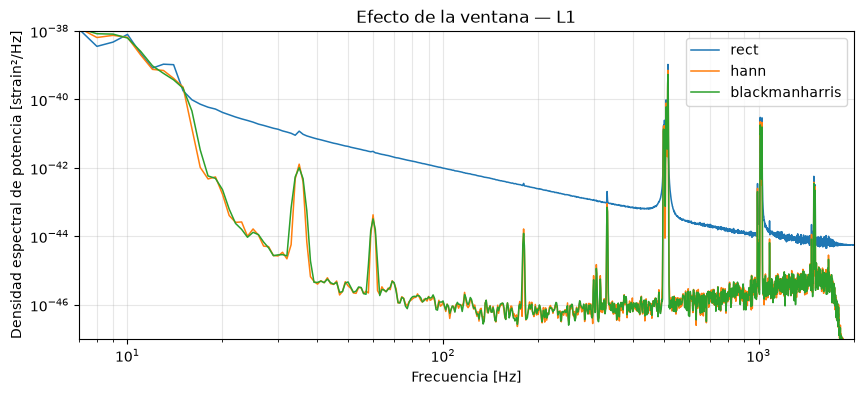

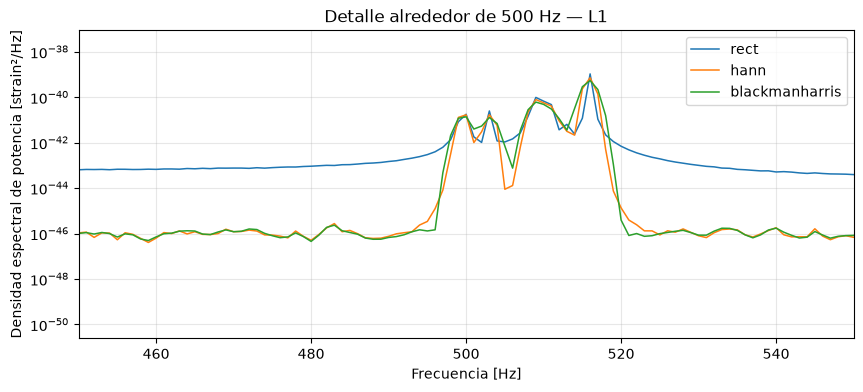

In [6]:
def ancho_pico(f, S, f0, ancho=30):                            # mido el ancho del pico a -3 dB
    banda = (f > f0-ancho) & (f < f0+ancho)                    # me quedo con la zona del pico
    fb, Sb = f[banda], S[banda]                                # recorto
    pico = Sb.max()                                            # el valor máximo del pico
    sobre = fb[Sb > pico/2]                                    # las frecuencias donde estoy arriba de la mitad
    return sobre.max() - sobre.min()                           # el ancho en Hz

def comparar_ventanas(x, fs, detector):
    plt.figure()                                               # gráfico de todo el espectro
    for vent in ["rect", "hann", "blackmanharris"]:            # las tres ventanas a comparar
        f_v, S_v, K_v = periodogram_averaging(x, L=L_cmp, fs=fs,   # mismo L y overlap siempre
                                              overlap=overlap_cmp, ventana=vent)
        plt.loglog(f_v, S_v, lw=1.1, label=vent)               # la curva
        print(f"  {vent:15s}: σ = {dispersion_db(f_v, S_v):.2f} dB, "   # varianza
              f"ancho pico 500 Hz = {ancho_pico(f_v, S_v, 500):.1f} Hz, "  # resolución
              f"piso 30 Hz = {S_v[np.argmin(abs(f_v-30))]:.2e}")   # cuánto leakage me queda abajo

    plt.xlim(7, 2000)                                          #
    plt.ylim(1e-47, 1e-38)                                     #
    plt.xlabel("Frecuencia [Hz]")                              #
    plt.ylabel("Densidad espectral de potencia [strain²/Hz]")  #
    plt.title(f"Efecto de la ventana — {detector}")            #
    plt.legend()                                               #
    plt.grid(True, which="both", alpha=0.3)                    #

    plt.figure()                                               # zoom en la línea de 500 Hz
    for vent in ["rect", "hann", "blackmanharris"]:            # las mismas tres
        f_v, S_v, K_v = periodogram_averaging(x, L=L_cmp, fs=fs,
                                              overlap=overlap_cmp, ventana=vent)
        plt.semilogy(f_v, S_v, lw=1.1, label=vent)             #

    plt.xlim(450, 550)                                         #
    plt.xlabel("Frecuencia [Hz]")                              #
    plt.ylabel("Densidad espectral de potencia [strain²/Hz]")  #
    plt.title(f"Detalle alrededor de 500 Hz — {detector}")     #
    plt.legend()                                               #
    plt.grid(True, which="both", alpha=0.3)                    #

comparar_ventanas(x_h, fs_h, "H1")                             # corro la comparación para Hanford
comparar_ventanas(x_l, fs_l, "L1")                             # y para Livingston

> **Respuesta.**

Para comparar los tres métodos se utilizó en todos los casos el mismo tramo de
$N = 16384$ muestras de ruido, de modo que las diferencias observadas se deban al
estimador y no a los datos utilizados. Para periodogram smoothing y periodogram
averaging se tomó $L = 4096$, ya que en los puntos anteriores este valor resultó
necesario para conservar las líneas espectrales y la forma del ruido a bajas
frecuencias. Para periodogram averaging se utilizó además un overlap del 50%,
obteniéndose $K = 7$ segmentos.

El periodograma presenta la mayor resolución espectral, ya que utiliza las
$N = 16384$ muestras en una única DFT, resultando $\Delta f = 0{,}25\,\mathrm{Hz}$. Sin embargo,
la estimación presenta una variación muy grande entre bins de frecuencia. Aumentar
$N$ mejora la resolución pero no soluciona directamente este problema de varianza.

El periodogram smoothing disminuye esta variación al suavizar el espectro mediante
el ventaneo de la autocorrelación. El costo es un aumento del sesgo y una pérdida
de resolución: al disminuir $L$ las líneas angostas se ensanchan o desaparecen y
el piso espectral se modifica considerablemente. Con $L = 4096$ el resultado mejora,
pero conserva una fuerte dependencia de la elección de la ventana de correlación.

El periodogram averaging produce un compromiso más conveniente. Con $L = 4096$ la
separación entre bins es de aproximadamente $1\,\mathrm{Hz}$, por lo que se pierde resolución
respecto del periodograma original, pero se obtiene una reducción de la varianza
gracias al promedio de los $K = 7$ segmentos. Al mismo tiempo, las principales
características del espectro siguen siendo visibles.
Como no conocemos la PSD verdadera del ruido de los detectores, el sesgo no puede
medirse directamente. Sin embargo, puede evaluarse indirectamente observando cuánto
se deforman el piso espectral y las líneas conocidas al cambiar los parámetros y
las ventanas.

Finalmente se hizo una comparación entre una ventana rectangular, una de Blackman-Harris, y
 una ventana Hann manteniendo fijos $L = 4096$ y el overlap en $50\,\%$. La rectangular posee un lóbulo principal más
angosto y por lo tanto mejor resolución, pero sus lóbulos laterales producen mayor
leakage espectral. Esto es especialmente importante en este problema debido al
enorme rango dinámico entre el ruido sísmico de bajas frecuencias y el resto del
espectro. La ventana Hann reduce considerablemente los lóbulos laterales y por lo
tanto el leakage, a costa de ensanchar los picos espectrales. A su vez, si bien tiene resultados similares a la Hann, vemos que al hacer 
zoom entre picos cercanos entre sí, la Hann presenta más detalle de la separación entre ellos. Mientras que la Hann tiene picos más pronunciados
y puntiagudos, la Blackman-Harris los hace más redondeados, bajando la resolución espectral. Así entonces se pudo ver la diferencia entre una ventana
con que genera picos muy anchos y poco leakage espectral (B-H), otra que tiene esa relación de compromiso invertida (rectangular) y un "punto medio" entre ambas. 
Por lo tanto, entre las alternativas analizadas se elige **periodogram averaging
con ventana Hann, $L = 4096$ y overlap del $50\,\%$** como estimador de la PSD del ruido
para los puntos siguientes. Se sacrifica parte de la resolución espectral a cambio
de una estimación menos variable y menos afectada por leakage.

### 2.e — H1 contra L1

Comparen las estimaciones de H1 y L1 entre sí: picos espectrales, artefactos, sesgo, varianza y cualquier otra cosa que les llame la atención. Atribuyan un origen a las componentes tonales que encuentren. ¿Cómo se compara lo que midieron con la curva esquemática de la presentación?

> **Respuesta.** *(completar)*

Esta respuesta fue abordada comparando los gráficos en puntos anteriores. Comparando los tres gráficos de 2.c, lo primero que se ve es que las dos centrales tienen la misma forma general: el muro sísmico abajo de 20 Hz, la caída suave en el medio y las líneas espectrales arriba de 300 Hz. Eso confirma que son dos instrumentos iguales midiendo el mismo tipo de ruido. Las diferencias están en las líneas. En L1 el pico de 500 Hz es muchísimo más grande que en H1, mientras que en H1 los que se destacan son los de 1000 y 1400 Hz. Como son los modos de las fibras de silicio que sostienen los espejos, tiene sentido que cada instalación tenga los suyos con distinta amplitud: dependen del armado mecánico particular de cada uno. La línea de 60 Hz y sus armónicos aparecen en las dos, porque las dos están conectadas a la misma red eléctrica.

Comparando con la curva esquemática de la presentación, la forma no me coincide: la curva de diseño tiene un mínimo entre 100 y 300 Hz y después vuelve a subir por el shot noise, y a mí el piso me sigue bajando hasta 2000 Hz. Eso me hace pensar que todavía tengo leakage de la ventana rectangular tapando el piso real. Lo verifico en 2.d comparando contra una ventana con taper.

### 2.f — Estacionariedad

**Validen la estacionariedad** de las señales. Investiguen técnicas de validación y aplíquenlas. ¿Sobre qué horizonte temporal es razonable tratar el ruido como estacionario?

H1
    16 s : dispersión = 1.30 dB
    32 s : dispersión = 1.53 dB
    64 s : dispersión = 1.63 dB
   128 s : dispersión = 1.69 dB
   256 s : dispersión = 1.72 dB
L1
    16 s : dispersión = 1.26 dB
    32 s : dispersión = 1.52 dB
    64 s : dispersión = 1.59 dB
   128 s : dispersión = 1.68 dB
   256 s : dispersión = 1.72 dB


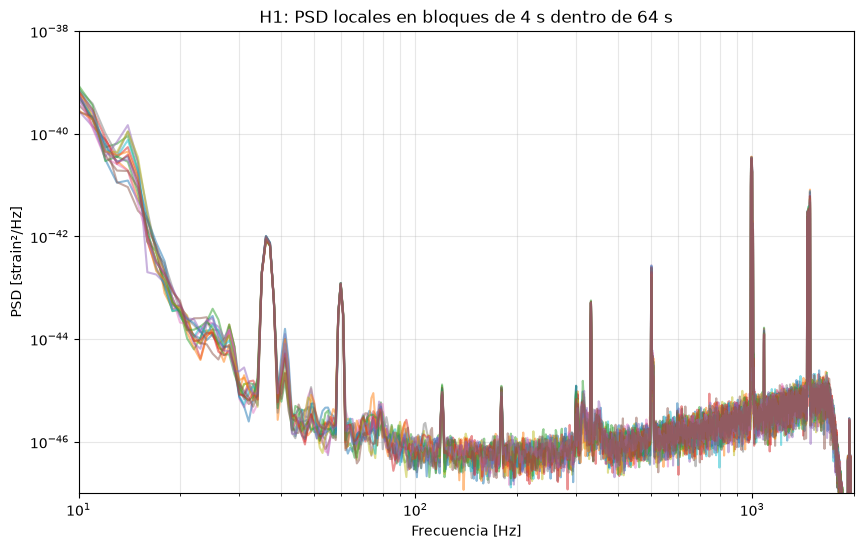

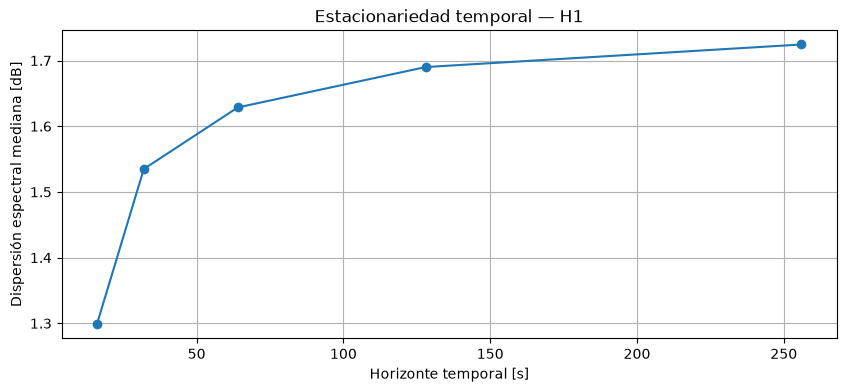

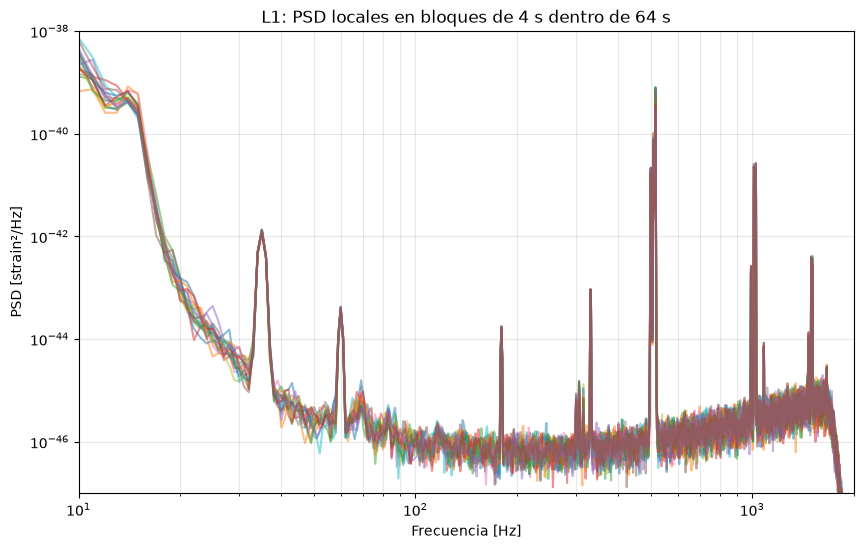

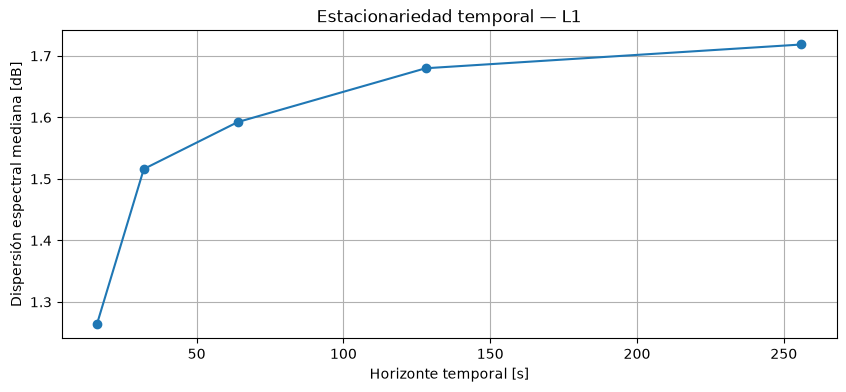

In [7]:
# Validación de estacionariedad usando PSD local.
#
# La idea es dividir un tramo de ruido en bloques cortos.
# Si el proceso es aproximadamente estacionario, la PSD estimada
# en esos bloques debería mantenerse aproximadamente constante.

def psd_locales(x, fs, T_bloque=4.0, L=4096):
    """
    Divide x en bloques de T_bloque segundos y estima una PSD
    en cada uno usando periodogram averaging + Hann.
    """
    Nbloque = int(T_bloque * fs)
    Kbloques = len(x) // Nbloque

    psds = []
    tiempos = []

    for k in range(Kbloques):
        xi = x[k*Nbloque : (k+1)*Nbloque]

        f, S, _ = periodogram_averaging(
            xi,
            L=L,
            fs=fs,
            overlap=0.5,
            ventana="hann"
        )

        psds.append(S)
        tiempos.append((k + 0.5) * T_bloque)

    return f, np.array(psds), np.array(tiempos)


def analizar_estacionariedad(strain, t0, fs, detector,
                              horizontes=[16, 32, 64, 128, 256],
                              margen_evento=2.0,
                              T_bloque=4.0):

    i_evento = int((GPS_EVENTO - t0) * fs)

    dispersiones = []

    for T in horizontes:
        N = int(T * fs)

        # Tomo T segundos inmediatamente anteriores al evento,
        # terminando margen_evento segundos antes.
        i_fin = i_evento - int(margen_evento * fs)
        i_ini = i_fin - N

        x = strain[i_ini:i_fin]

        f, psds, tiempos = psd_locales(
            x,
            fs,
            T_bloque=T_bloque,
            L=4096
        )

        # Banda donde queremos comparar la forma del ruido.
        # Evito la región sísmica más extrema y Nyquist.
        banda = (f >= 30) & (f <= 1000)

        # Paso las PSD a dB.
        psds_db = 10*np.log10(psds[:, banda])

        # Para cada frecuencia calculo cuánto cambia entre bloques.
        std_por_f = np.std(psds_db, axis=0)

        # Un único número representativo del cambio espectral.
        dispersion = np.median(std_por_f)
        dispersiones.append(dispersion)

        # Para un horizonte representativo muestro todas las PSD.
        if T == 64:
            plt.figure(figsize=(10, 6))

            for S in psds:
                plt.loglog(f, S, alpha=0.5)

            plt.xlim(10, 2000)
            plt.ylim(1e-47, 1e-38)
            plt.xlabel("Frecuencia [Hz]")
            plt.ylabel("PSD [strain²/Hz]")
            plt.title(
                f"{detector}: PSD locales en bloques de "
                f"{T_bloque:.0f} s dentro de {T} s"
            )
            plt.grid(True, which="both", alpha=0.3)

    # Cómo aumenta la variación al aumentar el horizonte temporal
    plt.figure()

    plt.plot(horizontes, dispersiones, "o-")
    plt.xlabel("Horizonte temporal [s]")
    plt.ylabel("Dispersión espectral mediana [dB]")
    plt.title(f"Estacionariedad temporal — {detector}")
    plt.grid(True)

    print(detector)
    for T, d in zip(horizontes, dispersiones):
        print(f"  {T:4d} s : dispersión = {d:.2f} dB")

    return np.array(horizontes), np.array(dispersiones)


Th, dh = analizar_estacionariedad(
    strainh, t0h, fs_h, "H1"
)

Tl, dl = analizar_estacionariedad(
    strainl, t0l, fs_l, "L1"
)

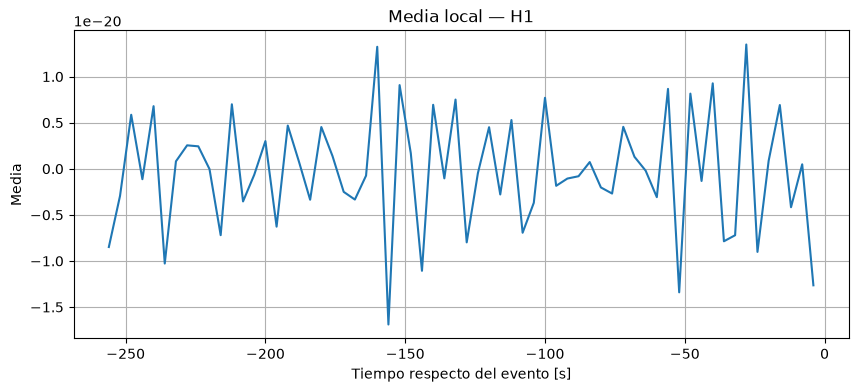

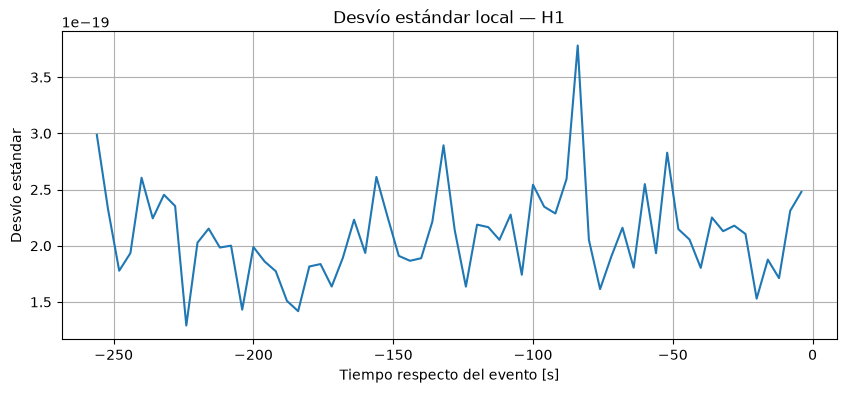

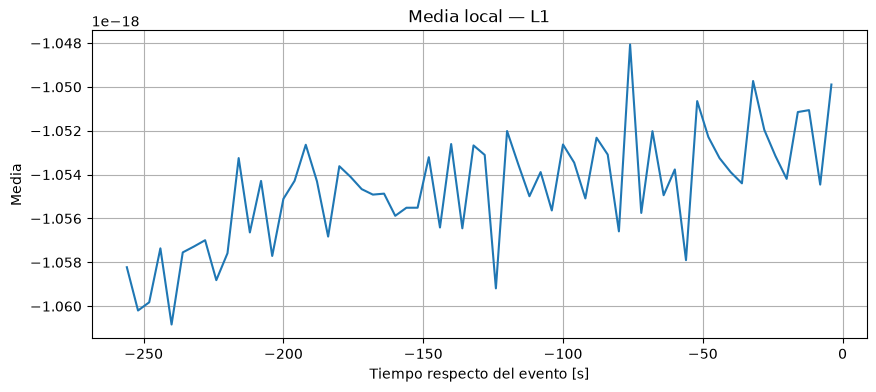

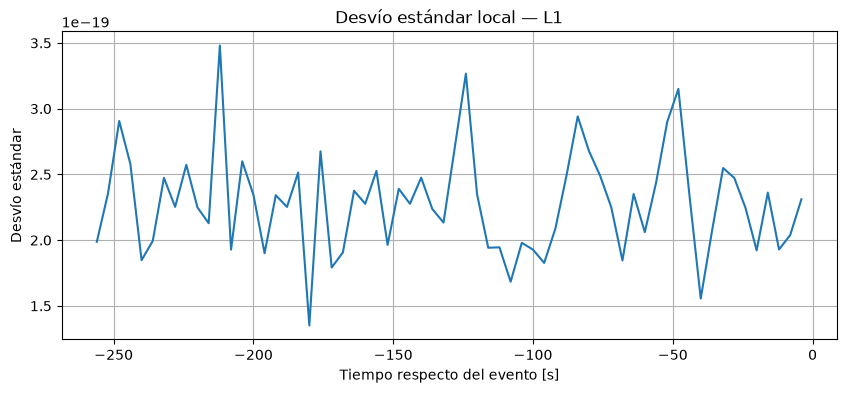

In [8]:
# Corroboración de estimadores de media y varianza para cada tramo

def estadisticas_temporales(strain, t0, fs, detector,
                            T_total=256, T_bloque=4,
                            margen_evento=2):

    i_evento = int((GPS_EVENTO - t0) * fs)
    i_fin = i_evento - int(margen_evento * fs)
    i_ini = i_fin - int(T_total * fs)

    x = strain[i_ini:i_fin]

    Nbloque = int(T_bloque * fs)
    K = len(x) // Nbloque

    medias = []
    stds = []
    tiempos = []

    for k in range(K):
        xi = x[k*Nbloque:(k+1)*Nbloque]

        medias.append(np.mean(xi))
        stds.append(np.std(xi))
        tiempos.append(
            -T_total + (k + 0.5)*T_bloque - margen_evento
        )

    plt.figure()
    plt.plot(tiempos, medias)
    plt.xlabel("Tiempo respecto del evento [s]")
    plt.ylabel("Media")
    plt.title(f"Media local — {detector}")
    plt.grid(True)

    plt.figure()
    plt.plot(tiempos, stds)
    plt.xlabel("Tiempo respecto del evento [s]")
    plt.ylabel("Desvío estándar")
    plt.title(f"Desvío estándar local — {detector}")
    plt.grid(True)


estadisticas_temporales(strainh, t0h, fs_h, "H1")
estadisticas_temporales(strainl, t0l, fs_l, "L1")

> **Respuesta.**
>
> Para estudiar la estacionariedad del ruido se dividió el registro en bloques
> locales de 4 s y se estimó una PSD en cada uno mediante periodogram averaging
> con ventana Hann, segmentos de 1 s y 50% de overlap.
>
> Al comparar las PSD locales dentro de un horizonte de 64 s, se observa que
> mantienen aproximadamente la misma forma espectral, el mismo piso de ruido y
> las mismas líneas principales. Las diferencias entre bloques son relativamente
> pequeñas y no muestran una tendencia sistemática clara.
>
> También se evaluó la dispersión espectral al aumentar el horizonte temporal.
> Esta dispersión crece al considerar intervalos cada vez más largos, aunque el
> crecimiento se vuelve moderado para horizontes mayores a aproximadamente
> 64–128 s.
>
> Por lo tanto, para este conjunto de datos resulta razonable tratar el ruido de
> LIGO como aproximadamente estacionario en escalas del orden de decenas de
> segundos. En particular, se adopta un horizonte de 64 s como una elección
> conservadora para los análisis posteriores.

---

## 3. Whitening

Con la mejor estimación del punto 2, realicen el **whitening** de los 32 s alrededor del evento: en el dominio de la frecuencia, normalicen cada componente por la amplitud espectral del ruido. Referencia útil: [los tutoriales de GWOSC](https://gwosc.org/tutorials/).

In [9]:
# Cargo los archivos cortos de 32 s alrededor del evento
h1_evento, t0h_corto, dth_corto = leer_strain(h1_corto)
l1_evento, t0l_corto, dtl_corto = leer_strain(l1_corto)

fs_h_corto = 1 / dth_corto
fs_l_corto = 1 / dtl_corto

print(f"H1 corto: {len(h1_evento)/fs_h_corto:.1f} s")
print(f"L1 corto: {len(l1_evento)/fs_l_corto:.1f} s")


# ----------------------------------------------------------
# PSD de ruido de referencia
# ----------------------------------------------------------
# Uso 64 s previos al evento, terminando 2 s antes.
# Así evito contaminar la PSD con GW150914.

T_ruido = 64.0
margen = 2.0

def tramo_ruido_pre_evento(strain, t0, fs, T=64, margen=2):
    i_evento = int((GPS_EVENTO - t0) * fs)
    i_fin = i_evento - int(margen * fs)
    i_ini = i_fin - int(T * fs)

    return strain[i_ini:i_fin]


ruido_h = tramo_ruido_pre_evento(
    strainh, t0h, fs_h, T=T_ruido, margen=margen
)

ruido_l = tramo_ruido_pre_evento(
    strainl, t0l, fs_l, T=T_ruido, margen=margen
)


# PSD con el método elegido en 2.d
f_psd_h, S_psd_h, K_h = periodogram_averaging(
    ruido_h,
    L=4096,
    fs=fs_h,
    overlap=0.5,
    ventana="hann"
)

f_psd_l, S_psd_l, K_l = periodogram_averaging(
    ruido_l,
    L=4096,
    fs=fs_l,
    overlap=0.5,
    ventana="hann"
)

print(f"K H1 = {K_h}")
print(f"K L1 = {K_l}")


# ----------------------------------------------------------
# Whitening
# ----------------------------------------------------------

def whitening(x, fs, f_psd, S_psd):
    """
    Whitening en frecuencia usando una PSD unilateral.

    Xw[k] = X[k] * sqrt(2/fs) / sqrt(Sn[k])

    Con esta normalización, ruido con PSD Sn(f)
    queda aproximadamente con varianza unitaria.
    """

    N = len(x)

    # FFT del tramo a whitenear
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, 1/fs)

    # Interpolo la PSD al grillado de frecuencia de esta FFT.
    # Interpolo en log para manejar mejor el gran rango dinámico.
    S_safe = np.maximum(S_psd, 1e-60)

    interp_log_psd = interp1d(
        f_psd,
        np.log(S_safe),
        kind="linear",
        bounds_error=False,
        fill_value=(np.log(S_safe[0]), np.log(S_safe[-1]))
    )

    Sn = np.exp(interp_log_psd(f))

    # Evito dividir DC por un valor extremadamente pequeño
    Xw = X * np.sqrt(2/fs) / np.sqrt(Sn)
    Xw[0] = 0.0

    # Regreso al dominio temporal
    xw = np.fft.irfft(Xw, n=N)

    return xw, f, Sn


h1_white, fwh, Snh = whitening(
    h1_evento,
    fs_h_corto,
    f_psd_h,
    S_psd_h
)

l1_white, fwl, Snl = whitening(
    l1_evento,
    fs_l_corto,
    f_psd_l,
    S_psd_l
)


# Verificación rápida
print("STD H1 whitened:", np.std(h1_white))
print("STD L1 whitened:", np.std(l1_white))

H1 corto: 32.0 s
L1 corto: 32.0 s
K H1 = 127
K L1 = 127
STD H1 whitened: 5.951777816915675
STD L1 whitened: 2.9916043028296024


> **Whitening.**
>
> Para realizar el whitening se utilizó como modelo del ruido la estimación
> seleccionada en el punto 2: periodogram averaging con ventana Hann,
> $L=4096$ y 50% de overlap.
>
> La PSD se estimó utilizando 64 s de datos previos al evento, terminando
> 2 s antes de GW150914. Esta elección se basa en el análisis de
> estacionariedad del punto 2.f, donde se observó que el ruido mantiene
> aproximadamente sus propiedades espectrales en esta escala temporal.
>
> Como la FFT de la señal de 32 s posee *bines* de frecuencias distintos
> de la utilizada para estimar la PSD, se interpoló la PSD a las frecuencias
> de la FFT del evento.
>
> El whitening se realizó en el dominio frecuencial mediante
>
> $$
> X_w(f)=X(f)\frac{\sqrt{2/f_s}}{\sqrt{S_n(f)}}.
> $$
>
> $\sqrt{S_n(f)}$ divide para "decolorear" el ruido actuando como un ecualizador, mientras que el factor $\sqrt{2/f_s}$ está para normalizar la varianza del ruido. Esto último sale de:
> 
> $$\sigma_w^2 = \int_0^{f_s/2} S_w(f)\,df$$
> 
> Si queremos $\sigma_w^2 = 1$ y además $S_w(f)=C$ constante:
> 
> $$1 = \int_0^{f_s/2} C\,df = C\frac{f_s}{2}\Rightarrow C = \frac{2}{f_s}$$
> 
> Como $S_w(f)=|H(f)|^2S_n(f)$:
> 
> $$|H(f)|^2S_n(f)=\frac{2}{f_s}\Rightarrow |H(f)|^2=\frac{2}{f_sS_n(f)}\Rightarrow H(f)=\frac{\sqrt{2/f_s}}{\sqrt{S_n(f)}}$$
> 
> $$\therefore\;X_w(f)=X(f)\frac{\sqrt{2/f_s}}{\sqrt{S_n(f)}}$$
> De esta manera, las componentes donde el detector presenta mayor ruido son atenuadas más fuertemente, mientras que las regiones de mayor
> sensibilidad adquieren mayor peso relativo.

### 3.a — Filtrado y visualización

Filtren pasabanda en la región de mayor sensibilidad, justificando los límites a partir de sus estimaciones del punto 2, y grafiquen la señal en el tiempo para ambos detectores. Deberían ver el chirp.

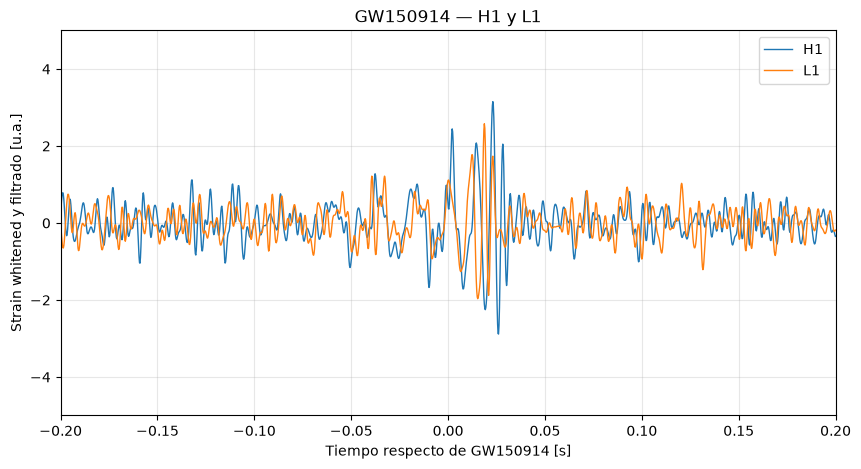

In [10]:
# Filtro pasabanda
f_low = 35
f_high = 350
orden = 4

sos = butter(
    orden,
    [f_low, f_high],
    btype="bandpass",
    fs=FS,
    output="sos"
)

h1_filt = sosfiltfilt(sos, h1_white)
l1_filt = sosfiltfilt(sos, l1_white)


# Tiempo relativo al evento
t_h = t0h_corto + np.arange(len(h1_filt)) / FS
t_l = t0l_corto + np.arange(len(l1_filt)) / FS

tau_h = t_h - GPS_EVENTO
tau_l = t_l - GPS_EVENTO


# Grafico alrededor del evento
plt.figure(figsize=(10, 5))

plt.plot(tau_h, h1_filt, label="H1", lw=1)
plt.plot(tau_l, l1_filt, label="L1", lw=1)

plt.xlim(-0.2, 0.2)
plt.ylim(-5,5)
plt.xlabel("Tiempo respecto de GW150914 [s]")
plt.ylabel("Strain whitened y filtrado [u.a.]")
plt.title("GW150914 — H1 y L1")
plt.grid(True, alpha=0.3)
plt.legend()

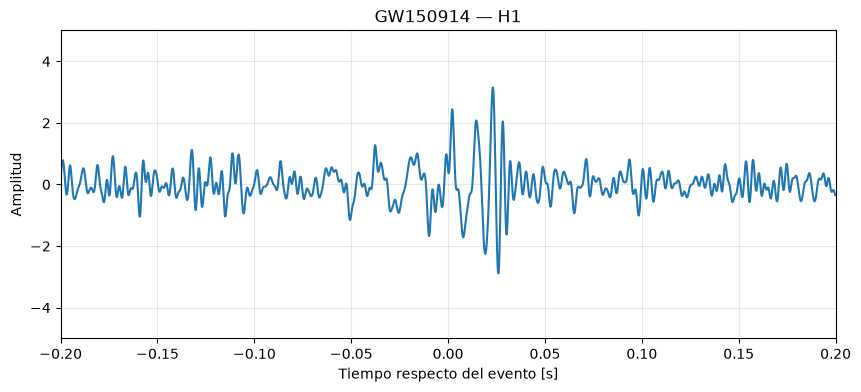

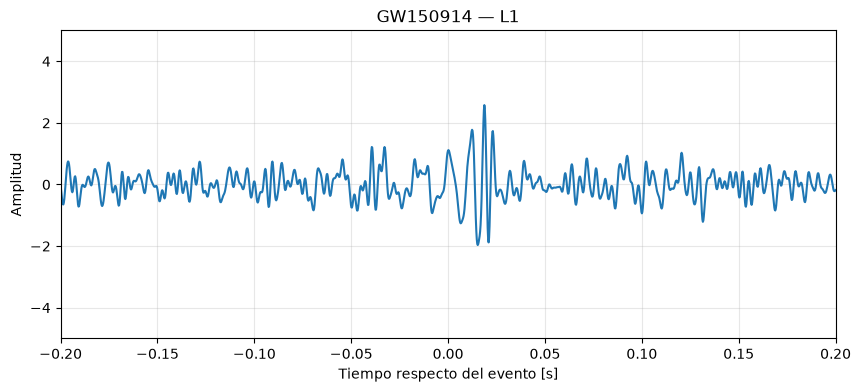

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(tau_h, h1_filt)
plt.xlim(-0.2, 0.2)
plt.ylim(-5,5)
plt.xlabel("Tiempo respecto del evento [s]")
plt.ylabel("Amplitud")
plt.title("GW150914 — H1")
plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 4))
plt.plot(tau_l, l1_filt)
plt.xlim(-0.2, 0.2)
plt.ylim(-5,5)
plt.xlabel("Tiempo respecto del evento [s]")
plt.ylabel("Amplitud")
plt.title("GW150914 — L1")
plt.grid(True, alpha=0.3)

> **Respuesta.**
>
> Luego del whitening se aplicó un filtro pasabanda Butterworth de orden 4
> entre 35 Hz y 350 Hz.
>
> El límite inferior permite rechazar la región dominada por ruido sísmico,
> que en las estimaciones del punto 2 crece fuertemente por debajo de
> aproximadamente 30--35 Hz. El límite superior conserva la banda donde se
> desarrolla GW150914 y elimina ruido de frecuencias superiores que no aporta
> información relevante al evento.
>
> Se utilizó `sosfiltfilt`, que aplica el filtro hacia adelante y hacia atrás
> y por lo tanto evita introducir un desplazamiento de fase neto. Esto es
> especialmente importante porque en el punto 4 se estimará el retardo entre
> H1 y L1 mediante correlación cruzada.
>
> Después del whitening y el filtrado puede distinguirse el chirp de
> GW150914: una oscilación cuya frecuencia y amplitud aumentan rápidamente
> durante aproximadamente los últimos 200 ms antes de la fusión.

### 3.b — Audio

Generen el audio. El resultado directo es difícil de escuchar: expliquen por qué y qué transformación adicional aplicaron.

In [12]:
from scipy.signal import hilbert
from pathlib import Path

In [13]:
def normalizar_audio(x):
    x = x / np.max(np.abs(x))
    return np.int16(0.95 * x * 32767)


# Extraigo solo una pequeña ventana alrededor del evento
mask_h = (tau_h >= -0.35) & (tau_h <= 0.15)
mask_l = (tau_l >= -0.35) & (tau_l <= 0.15)

audio_h = h1_filt[mask_h]
audio_l = l1_filt[mask_l]


# ----------------------------------------------------------
# Audio directo
# ----------------------------------------------------------

output_dir = Path("audio_output")
output_dir.mkdir(parents=True, exist_ok=True)

wavfile.write(
    "audio_output/GW150914_H1_directo.wav",
    int(FS),
    normalizar_audio(audio_h)
)

wavfile.write(
    "audio_output/GW150914_L1_directo.wav",
    int(FS),
    normalizar_audio(audio_l)
)


# ----------------------------------------------------------
# Corrimiento espectral hacia arriba
# ----------------------------------------------------------

def desplazar_frecuencia(x, fs, f_shift):
    """
    Desplaza aproximadamente todo el espectro +f_shift Hz
    usando la señal analítica.
    """
    z = hilbert(x)
    t = np.arange(len(x)) / fs

    z_shift = z * np.exp(1j * 2*np.pi * f_shift * t)

    return np.real(z_shift)


f_shift = 400  # Hz

audio_h_shift = desplazar_frecuencia(audio_h, FS, f_shift)
audio_l_shift = desplazar_frecuencia(audio_l, FS, f_shift)


wavfile.write(
    "audio_output/GW150914_H1_shift.wav",
    int(FS),
    normalizar_audio(audio_h_shift)
)

wavfile.write(
    "audio_output/GW150914_L1_shift.wav",
    int(FS),
    normalizar_audio(audio_l_shift)
)

print("Audios generados en audio_output/.")

Audios generados en audio_output/.


> **Respuesta.**
>
> Se generaron archivos de audio a partir de las señales whitened y
> pasabanda. Antes de guardarlos se normalizó la amplitud para utilizar
> adecuadamente el rango dinámico de un archivo WAV de 16 bits.
>
> El resultado directo es difícil de escuchar porque el evento dura solamente
> alrededor de 200 ms y gran parte de su energía se encuentra en frecuencias
> relativamente bajas, aproximadamente entre decenas y algunos cientos de Hz,
> donde la sensibilidad del oído humano es menor.
>
> Para mejorar la audibilidad se realizó un corrimiento en frecuencia de
> aproximadamente 400 Hz mediante la señal analítica obtenida con la
> transformada de Hilbert. De esta forma el contenido original de
> aproximadamente 35--350 Hz se desplaza hacia 435--750 Hz, conservando la
> evolución temporal del chirp.

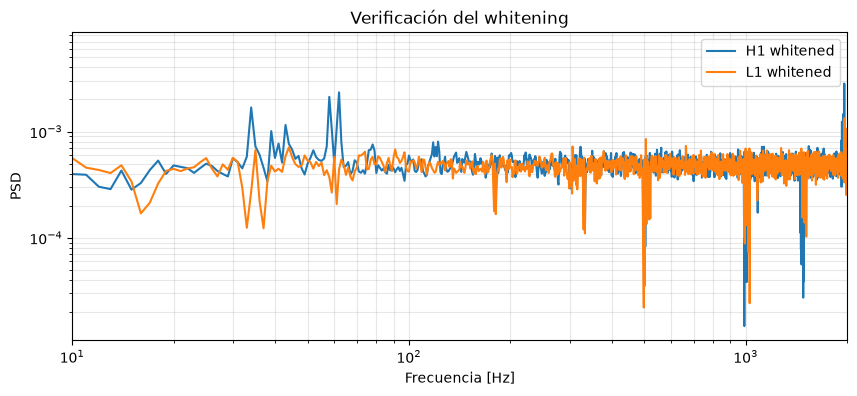

In [14]:
# Para verificar, podemos calcular los nuevos PSD luego del "decoloreado" 
# y ver que sea aproximadamente plano o blanco

f_check_h, S_check_h = welch(
    h1_white,
    fs=FS,
    nperseg=4096
)

f_check_l, S_check_l = welch(
    l1_white,
    fs=FS,
    nperseg=4096
)

plt.figure()
plt.loglog(f_check_h, S_check_h, label="H1 whitened")
plt.loglog(f_check_l, S_check_l, label="L1 whitened")

plt.xlim(10, 2000)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Verificación del whitening")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

---

## 4. Dirección de arribo (DOA)

Con las señales del punto anterior, estimen por **correlación cruzada** la diferencia de tiempo de arribo del evento entre H1 y L1.

### 4.a — Retardo

Reporten el retardo del pico y su signo: ¿qué detector recibió la señal primero?

> **Pista.** A $4096\,\mathrm{Hz}$ el intervalo entre muestras es de $244\,\mu\mathrm{s}$ y el retardo máximo posible es de $10\,\mathrm{ms}$. Evalúen si la resolución de una muestra les alcanza.

Retardo: 30 muestras
Δt = t_H1 - t_L1 = 7.324 ms
Correlación en el pico = -0.594
Resolución temporal = 244.1 µs
Retardo físico máximo = 10.01 ms
L1 recibió la señal primero.


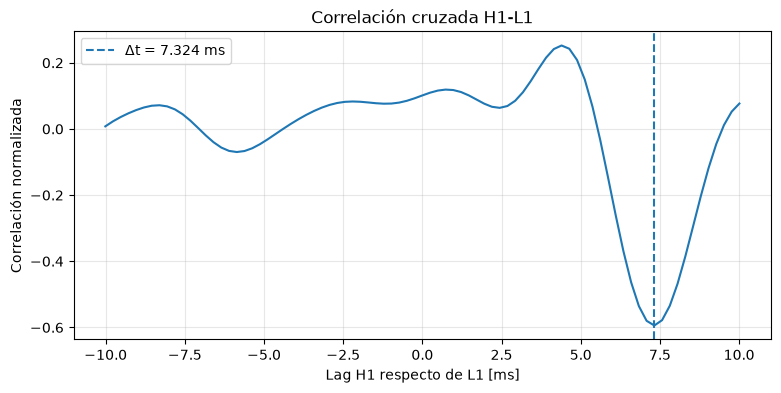

In [15]:
from scipy.signal import correlate, correlation_lags

# Uso solamente la zona donde está el chirp.
# No conviene correlacionar los 32 s completos porque casi todo sería ruido.
tmin = -0.25
tmax = 0.05

mask_h = (tau_h >= tmin) & (tau_h <= tmax)
mask_l = (tau_l >= tmin) & (tau_l <= tmax)

h = h1_filt[mask_h]
l = l1_filt[mask_l]

# Por seguridad, dejo ambas señales con igual longitud
Ncorr = min(len(h), len(l))
h = h[:Ncorr]
l = l[:Ncorr]

# Quito media y normalizo amplitud.
# Esto hace que la correlación compare principalmente la forma de las señales.
h = (h - np.mean(h)) / np.std(h)
l = (l - np.mean(l)) / np.std(l)

# Defino:
#   Δt = t_H1 - t_L1
#
# Con correlate(H1, L1):
#   lag > 0  -> H1 está retrasada respecto de L1 -> L1 llegó primero
#   lag < 0  -> L1 está retrasada respecto de H1 -> H1 llegó primero

corr = correlate(h, l, mode="full", method="fft")
lags = correlation_lags(len(h), len(l), mode="full")

# Normalización de la correlación
corr = corr / np.sqrt(np.sum(h**2) * np.sum(l**2))

# Sólo permito retardos físicamente posibles
c = 299_792_458          # m/s
d = 3002e3               # distancia H1-L1 [m]
dt_max = d / c

lags_s = lags / FS

mask_fisica = np.abs(lags_s) <= dt_max

lags_phys = lags[mask_fisica]
lags_phys_s = lags_s[mask_fisica]
corr_phys = corr[mask_fisica]

# H1 y L1 pueden aparecer aproximadamente invertidas debido a
# la distinta orientación de los detectores.
# Por eso busco el máximo de |correlación|.
i_peak = np.argmax(np.abs(corr_phys))

lag_samples = lags_phys[i_peak]
delta_t = lags_phys_s[i_peak]
corr_peak = corr_phys[i_peak]

print(f"Retardo: {lag_samples} muestras")
print(f"Δt = t_H1 - t_L1 = {delta_t*1e3:.3f} ms")
print(f"Correlación en el pico = {corr_peak:.3f}")
print(f"Resolución temporal = {1/FS*1e6:.1f} µs")
print(f"Retardo físico máximo = {dt_max*1e3:.2f} ms")

if delta_t > 0:
    print("L1 recibió la señal primero.")
elif delta_t < 0:
    print("H1 recibió la señal primero.")
else:
    print("No se observa retardo entre detectores.")


# Gráfico
plt.figure(figsize=(9, 4))

plt.plot(lags_phys_s * 1e3, corr_phys)
plt.axvline(delta_t * 1e3, ls="--", label=f"Δt = {delta_t*1e3:.3f} ms")

plt.xlabel("Lag H1 respecto de L1 [ms]")
plt.ylabel("Correlación normalizada")
plt.title("Correlación cruzada H1-L1")
plt.grid(True, alpha=0.3)
plt.legend()

> **Respuesta.**
>
> Para estimar el retardo se calculó la correlación cruzada entre las señales
> H1 y L1 obtenidas en el punto anterior, utilizando únicamente una ventana
> temporal alrededor del chirp. Se restringió la búsqueda a retardos
> físicamente posibles, $|\Delta t| \leq d/c \approx 10$ ms.
>
> Se definió $\Delta t = t_{H1}-t_{L1}$. Por lo tanto, un retardo positivo
> indica que la señal aparece más tarde en H1 y que L1 recibió la onda primero.
>
> El máximo en valor absoluto de la correlación se obtuvo para un retardo de
> aproximadamente **7.32 ms (30 muestras)**. El signo indica que
> **L1 recibió la señal primero**.
>
> El intervalo de muestreo es
> $T_s=1/4096 \approx 244\,\mu\text{s}$, por lo que la estimación del retardo sólo
> puede variar en pasos de aproximadamente 0.244 ms.

### 4.b — Ángulo de cono

Calculen el **ángulo del cono de arribo** respecto de la línea que une ambos detectores, y comparen con el Anexo:

$$\cos\theta = \frac{c\,\Delta t}{d}$$

¿Por qué el resultado es un cono y no una dirección? ¿Qué haría falta para localizar la fuente en un punto?

In [16]:
# delta_t fue definido como t_H1 - t_L1.
# Con nuestro resultado debería ser positivo porque L1 llegó primero.

cos_theta = c * delta_t / d

# Protección contra pequeños errores numéricos
cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.degrees(np.arccos(cos_theta))

print(f"Δt medido = {delta_t*1e3:.3f} ms")
print(f"cos(theta) = {cos_theta:.4f}")
print(f"theta = {theta:.2f}°")

Δt medido = 7.324 ms
cos(theta) = 0.7314
theta = 42.99°


> **Respuesta.**
>
> El retardo entre ambos detectores está relacionado con el ángulo de arribo
> mediante
>
> $$\cos\theta = c\Delta t/d$$
>
> donde $d=3002$ km es la distancia entre Hanford y Livingston.
>
> Utilizando el retardo estimado en el punto anterior se obtiene
> $\theta \approx 43\degree$ respecto de la línea H1-L1.
>
> Con dos detectores no es posible determinar una dirección única. El retardo
> sólo fija la proyección de la dirección de propagación sobre la línea que une
> ambos observatorios. Todas las direcciones que forman el mismo ángulo
> $\theta$ con esa línea producen exactamente el mismo retardo.
>
> Geométricamente, esas direcciones forman un **cono** cuyo eje es la línea
> H1-L1. Al proyectarlo sobre la esfera celeste se obtiene un anillo de
> posibles posiciones de la fuente.
>
> Para localizar la fuente es necesario disponer de al menos un tercer
> detector no colineal, que aporta un segundo retardo independiente. La
> intersección de las restricciones temporales reduce fuertemente la región
> posible; información adicional de las respuestas angulares, amplitudes y
> polarización de los detectores permite resolver ambigüedades restantes.

---

## Anexo: valores de referencia

<details>
<summary><b>⚠️ No abrir antes de haber completado los puntos correspondientes — clic para desplegar</b></summary>

<br>

Sirve para **contrastar** sus resultados, no para orientarlos. Fuente: Abbott et al., *Observation of Gravitational Waves from a Binary Black Hole Merger*, Phys. Rev. Lett. 116, 061102 (2016).

**Evento** (puntos 2 y 3). GW150914 ocurrió el 14/09/2015 a las 09:50:45 UTC, GPS $1126259462{,}4$. La señal barre de $\sim 35\,\mathrm{Hz}$ a $\sim 250\,\mathrm{Hz}$ en unos $0{,}2\,\mathrm{s}$, completando unos 8 ciclos, con un *strain* pico de $1{,}0 \times 10^{-21}$.

**Sensibilidad** (punto 2.e). En la corrida O1, la amplitud espectral de ruido de ambos detectores alcanzó un mínimo del orden de $10^{-23}\,\mathrm{Hz}^{-1/2}$ entre $\sim 100$ y $\sim 300\,\mathrm{Hz}$, degradándose rápidamente por debajo de $20\,\mathrm{Hz}$.

**Retardo y localización** (punto 4). L1 registró el evento $6{,}9^{+0{,}5}_{-0{,}4}\,\mathrm{ms}$ **antes** que H1. Con solo dos detectores, la región de credibilidad al $90\,\%$ abarcó unos $600$ grados cuadrados.

</details>

---

## Extensiones opcionales

Para quienes quieran ir más allá: mostrar el evento en un **espectrograma**; verificar la hipótesis de **gaussianidad** del ruido, que es distinta de la de estacionariedad; usar las máscaras `DQmask` e `injmask` de los archivos para descartar tramos no utilizables e inyecciones de prueba; estimar el retardo con precisión **sub-muestral** y propagar la incertidumbre hasta $\theta$; explicar el signo del pico de correlación cruzada a partir de la orientación relativa de los brazos de ambos detectores.